In [4]:
%matplotlib inline

import mne
from mne.datasets import eegbci
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

mne.set_log_level('WARNING')


REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if 'notebooks' in os.getcwd() else os.getcwd()
RESULTS_DIR = os.path.join(REPO_ROOT, 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

subject = 1
runs = [6, 10]
raw_files = eegbci.load_data(subject, runs)
raw = mne.concatenate_raws([mne.io.read_raw_edf(f, preload=True) for f in raw_files])
raw_filtered = raw.copy().filter(l_freq=8., h_freq=30.)

events, event_id = mne.events_from_annotations(raw_filtered)
epochs = mne.Epochs(raw_filtered, events, event_id={'T1': 2, 'T2': 3},
                    tmin=0.0, tmax=4.0, baseline=None, preload=True)

X = epochs.get_data()
y = epochs.events[:, 2]

print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (30, 64, 641), y shape: (30,)


In [10]:
#classificators need 2d input (n_epochs, n_features)

motor_channels = ['C3..', 'Cz..', 'C4..']
channel_idx = [epochs.ch_names.index(ch) for ch in motor_channels]

X_features = np.var(X[:, channel_idx, :], axis=2)

print(f"Feature matrix shape: {X_features.shape}")
print(f"Used channels: {motor_channels}")

Feature matrix shape: (30, 3)
Used channels: ['C3..', 'Cz..', 'C4..']


In [11]:
# Pipeline: Scaling -> LDA classifier
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lda', LinearDiscriminantAnalysis())
])

# Cross-validation: 5-fold stratified
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X_features, y, cv=cv, scoring='accuracy')

print(f"Accuracy per fold: {np.round(scores * 100, 1)}")
print(f"Mean: {scores.mean() * 100:.1f}%")
print(f"Standard deviation: {scores.std() * 100:.1f}%")

Accuracy per fold: [83.3 50.  83.3 66.7 66.7]
Mean: 70.0%
Standard deviation: 12.5%


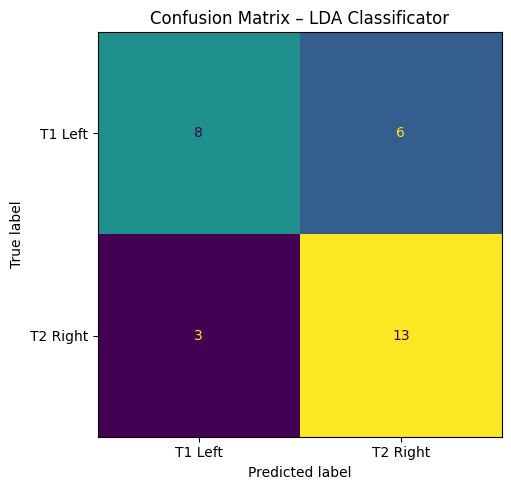


Correct classified: 21 von 30


In [13]:
pipeline.fit(X_features, y)
y_pred = pipeline.predict(X_features)

cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['T1 Left', 'T2 Right'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False)
ax.set_title('Confusion Matrix – LDA Classificator')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '04_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

print(f"\nCorrect classified: {np.sum(np.diag(cm))} of {len(y)}")